In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the final analytics data
df = pd.read_csv('final_analytics.csv')

In [2]:
# Parse date for time series (aggregate by month)
df['tw_date'] = pd.to_datetime(df['tw_date'])
df['month'] = df['tw_date'].dt.to_period('M')

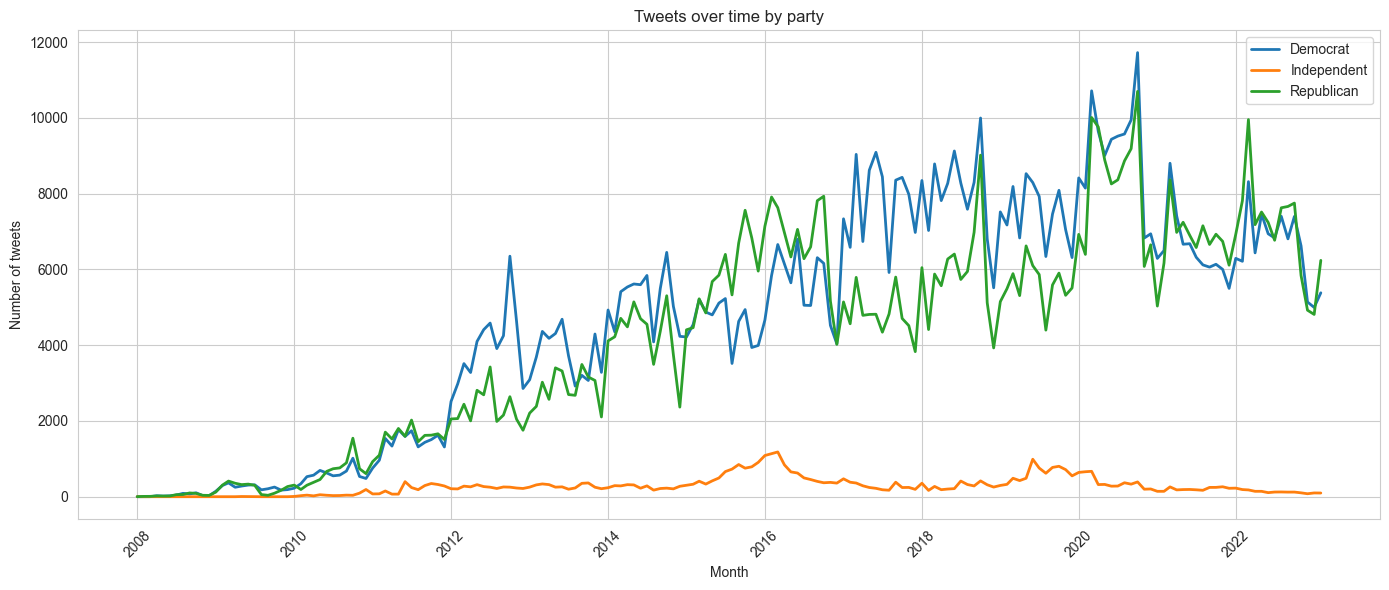

In [3]:
# 1. Tweets over time by party (by month)
tweets_by_party_month = df.groupby(['month', 'party']).size().reset_index(name='count')
tweets_pivot = tweets_by_party_month.pivot(index='month', columns='party', values='count').fillna(0)
tweets_pivot.index = tweets_pivot.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))
for party in tweets_pivot.columns:
    ax.plot(tweets_pivot.index, tweets_pivot[party], label=party, linewidth=2)

ax.set_xlabel('Month')
ax.set_ylabel('Number of tweets')
ax.set_title('Tweets over time by party')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

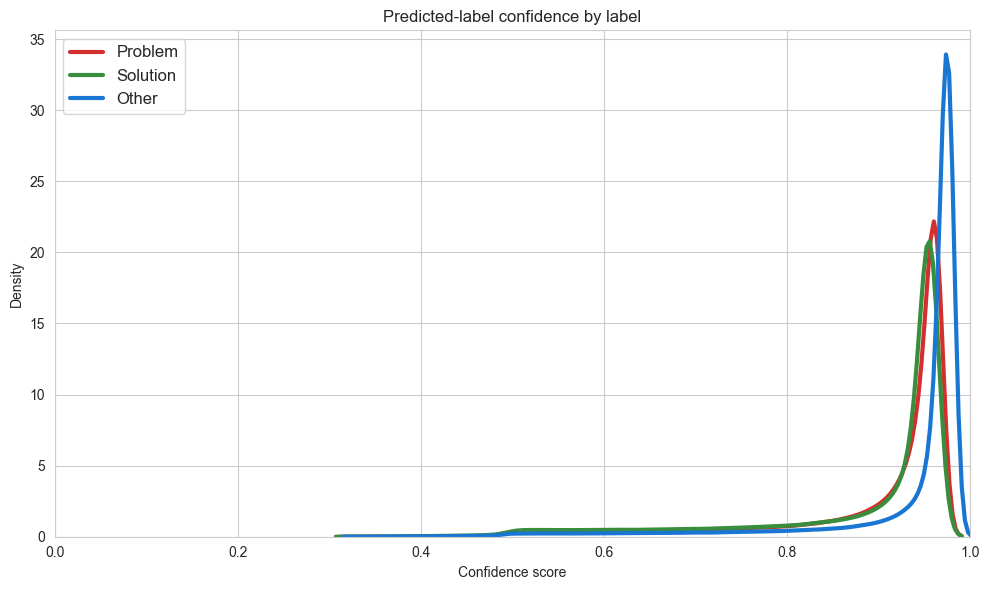

In [27]:
# 2. Confidence breakdown by label - 3 overlaid KDE curves (simple, easy to compare)
df_pred_conf = df.copy()
df_pred_conf['predicted_confidence'] = np.where(df['label'] == 'Problem', df['confidence_Problem'],
                                    np.where(df['label'] == 'Solution', df['confidence_Solution'], df['confidence_Other']))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#D32F2F', '#388E3C', '#1976D2']  # bold red, green, blue

for label, c in zip(['Problem', 'Solution', 'Other'], colors):
    subset = df_pred_conf[df_pred_conf['label'] == label]['predicted_confidence']
    sns.kdeplot(subset, ax=ax, label=label, color=c, linewidth=3)

ax.set_xlabel('Confidence score')
ax.set_ylabel('Density')
ax.set_title('Predicted-label confidence by label')
ax.set_xlim(0, 1)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

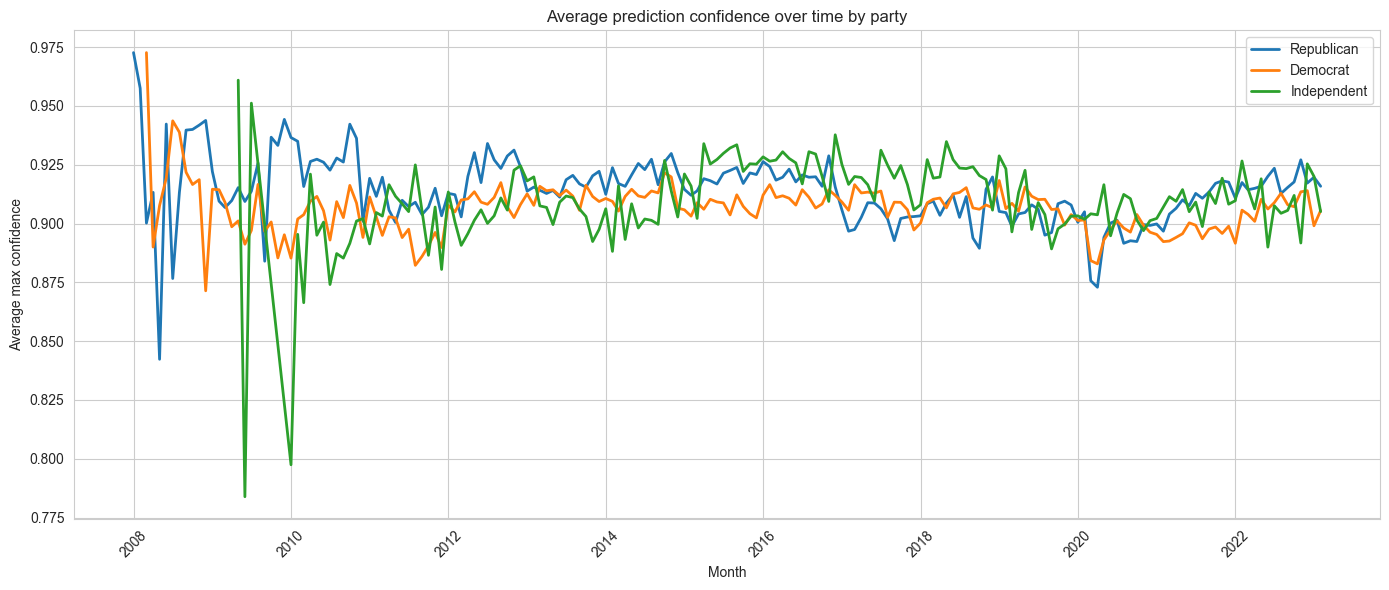

In [5]:
# 2b. Average confidence over time by party (by month)
avg_conf_by_party_month = df.groupby(['month', 'party'])['max_confidence'].mean().reset_index()
avg_conf_by_party_month['month_ts'] = avg_conf_by_party_month['month'].dt.to_timestamp()
fig, ax = plt.subplots(figsize=(14, 6))
for party in avg_conf_by_party_month['party'].unique():
    subset = avg_conf_by_party_month[avg_conf_by_party_month['party'] == party]
    ax.plot(subset['month_ts'], subset['max_confidence'], label=party, linewidth=2)

ax.set_xlabel('Month')
ax.set_ylabel('Average max confidence')
ax.set_title('Average prediction confidence over time by party')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

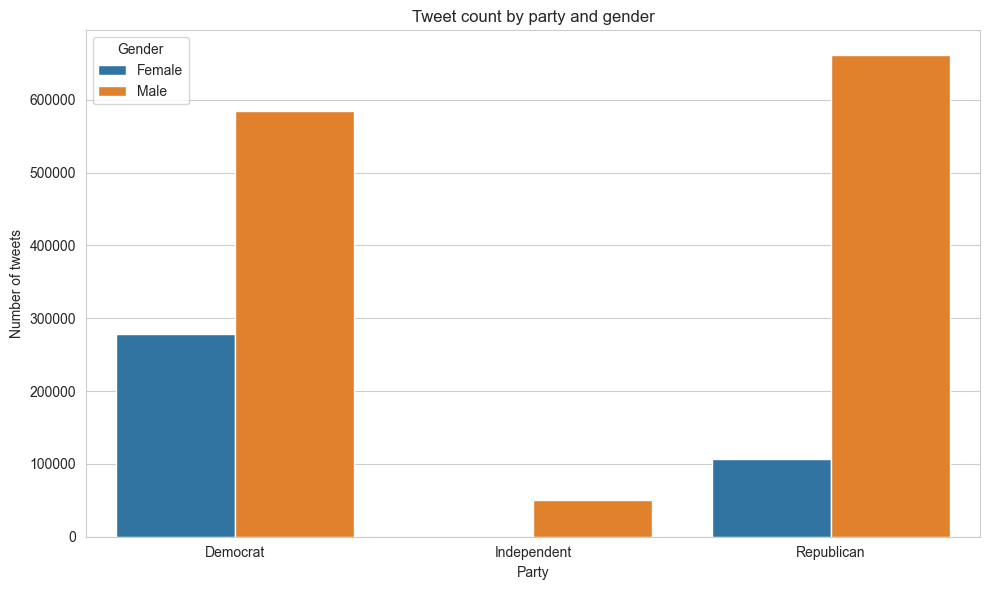

In [6]:
# 3. Breakdown by gender and party
gender_party_counts = df.groupby(['party', 'gender']).size().reset_index(name='count')
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=gender_party_counts, x='party', y='count', hue='gender', ax=ax)
ax.set_xlabel('Party')
ax.set_ylabel('Number of tweets')
ax.set_title('Tweet count by party and gender')
ax.legend(title='Gender')
plt.tight_layout()
plt.show()

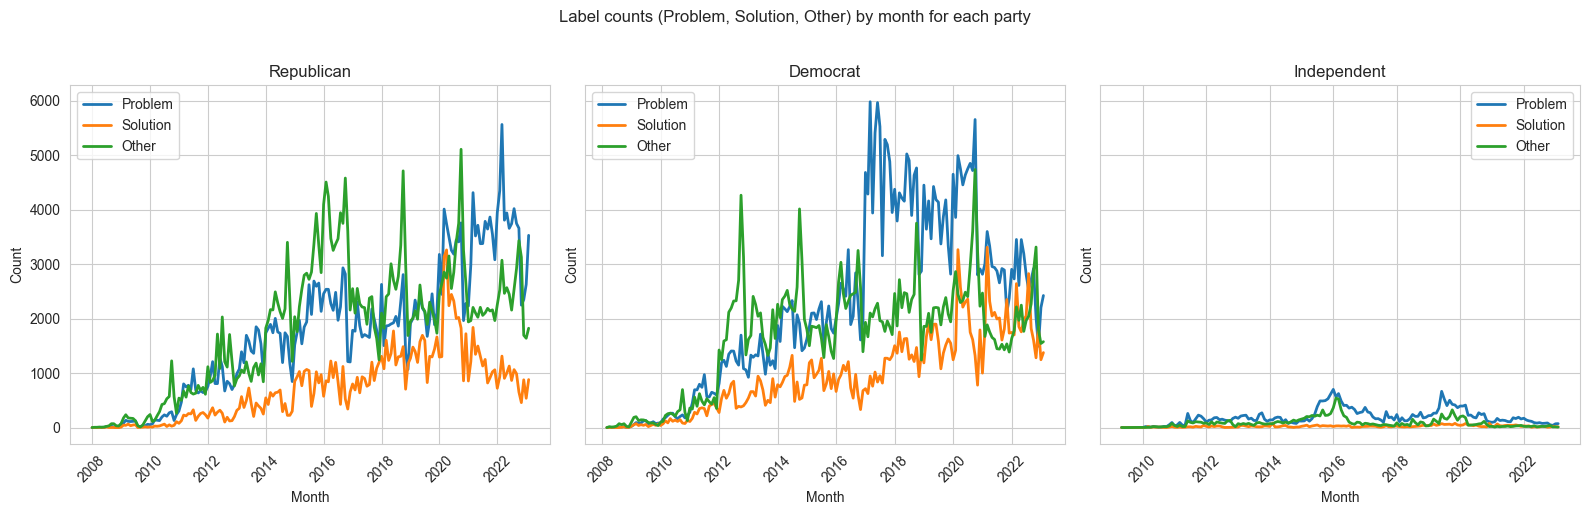

In [11]:
# 4. Problem, Solution, Other count by month - one subplot per party (shared axes)
label_by_party_month = df.groupby(['month', 'party', 'label']).size().reset_index(name='count')

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
parties = label_by_party_month['party'].unique()

for i, party in enumerate(parties):
    ax = axes[i]
    subset = label_by_party_month[label_by_party_month['party'] == party]
    pivot = subset.pivot(index='month', columns='label', values='count').fillna(0)
    pivot.index = pivot.index.to_timestamp()

    for label in ['Problem', 'Solution', 'Other']:
        if label in pivot.columns:
            ax.plot(pivot.index, pivot[label], label=label, linewidth=2)

    ax.set_xlabel('Month')
    ax.set_ylabel('Count')
    ax.set_title(f'{party}')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Label counts (Problem, Solution, Other) by month for each party', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

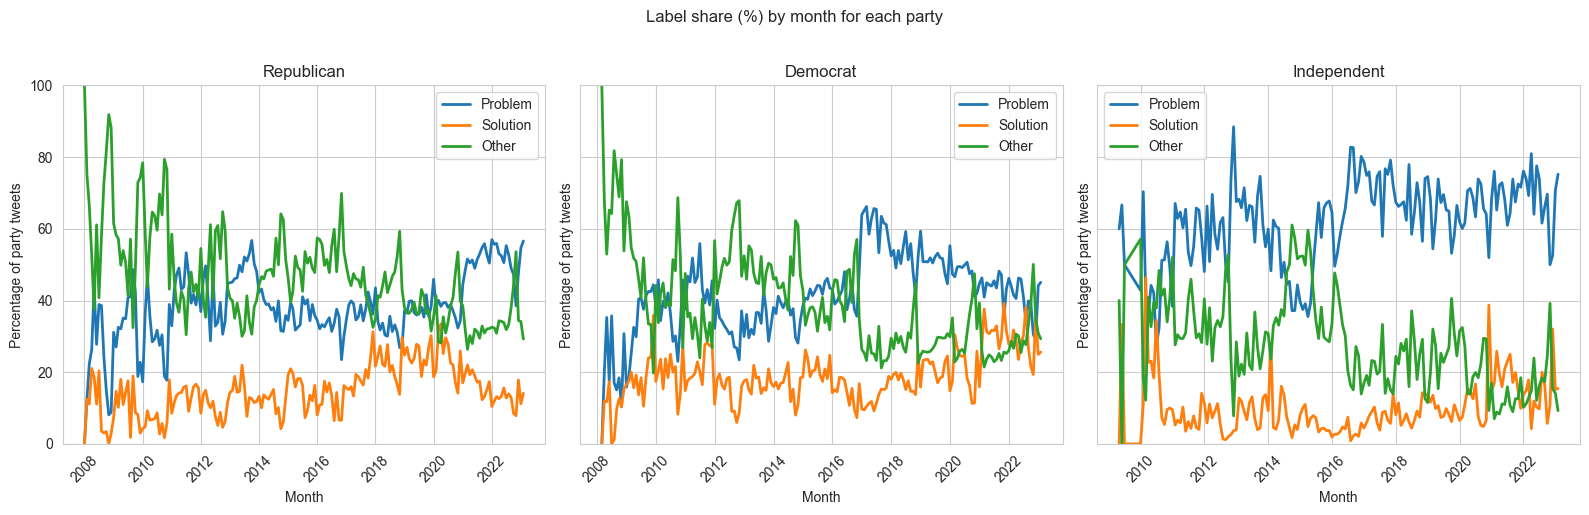

In [14]:
# 4b. Same as above but as percentage of each party's tweets per month (fair comparison across parties)
label_by_party_month_pct = df.groupby(['month', 'party', 'label']).size().unstack(fill_value=0)
label_by_party_month_pct = label_by_party_month_pct.div(label_by_party_month_pct.sum(axis=1), axis=0) * 100
label_by_party_month_pct = label_by_party_month_pct.reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
parties = label_by_party_month_pct['party'].unique()

for i, party in enumerate(parties):
    ax = axes[i]
    subset = label_by_party_month_pct[label_by_party_month_pct['party'] == party]
    subset = subset.set_index('month')
    subset.index = subset.index.to_timestamp()

    for label in ['Problem', 'Solution', 'Other']:
        if label in subset.columns:
            ax.plot(subset.index, subset[label], label=label, linewidth=2)

    ax.set_xlabel('Month')
    ax.set_ylabel('Percentage of party tweets')
    ax.set_title(f'{party}')
    ax.legend()
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Label share (%) by month for each party', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

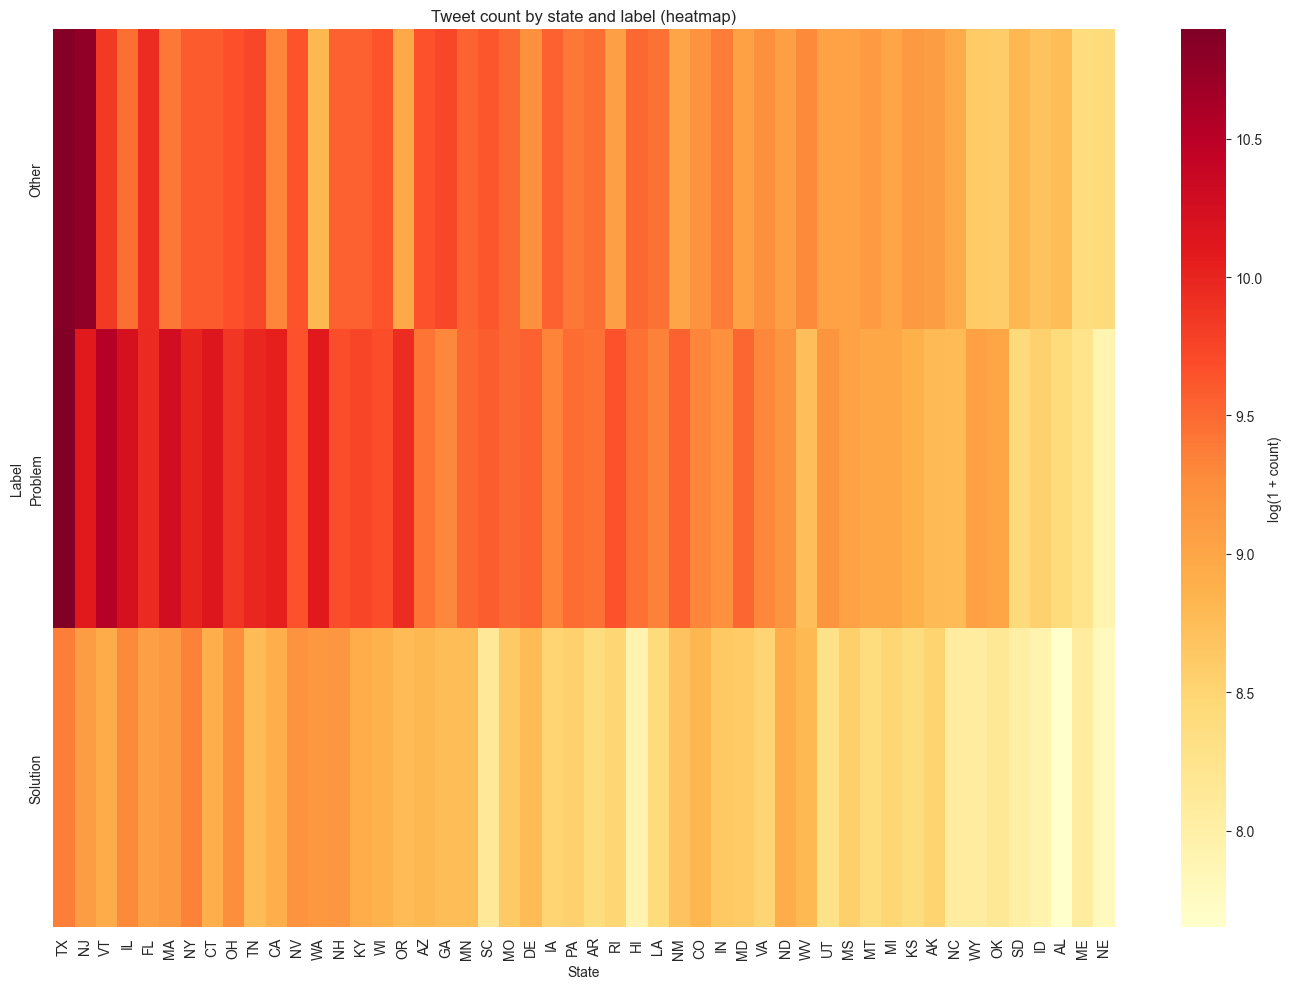

In [16]:
# 5. State heatmap - tweet count by state and label (log scale to handle high-count states)
state_counts = df.groupby('state').size().reset_index(name='count').sort_values('count', ascending=False)
state_label = df.groupby(['state', 'label']).size().unstack(fill_value=0)
state_label = state_label.reindex(state_counts['state']).fillna(0)
state_label_log = np.log1p(state_label)  # log scale so low-count states aren't washed out

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(state_label_log.T, annot=False, fmt='.1f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'log(1 + count)'})
ax.set_xlabel('State')
ax.set_ylabel('Label')
ax.set_title('Tweet count by state and label (heatmap)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

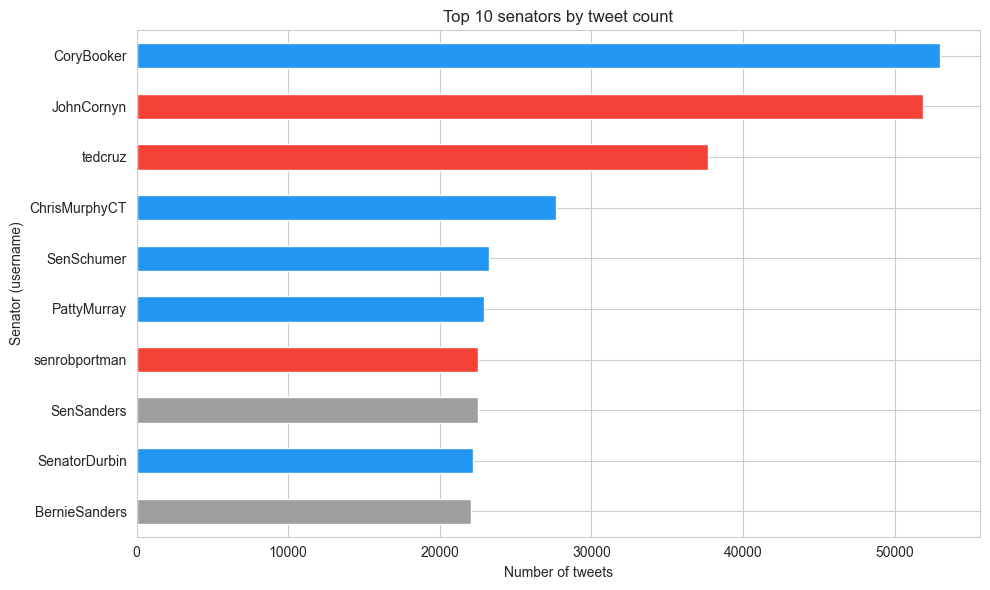

In [19]:
# 6. Top 10 senators by tweet count (colored by party)
senator_party = df.groupby('user_handle')['party'].first()
top_senators = df.groupby('user_handle').size().sort_values(ascending=False).head(10)
party_colors = {'Democrat': '#2196F3', 'Republican': '#F44336', 'Independent': '#9E9E9E'}
colors = [party_colors.get(senator_party.get(s, 'Independent'), '#9E9E9E') for s in top_senators.index]

fig, ax = plt.subplots(figsize=(10, 6))
top_senators.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Number of tweets')
ax.set_ylabel('Senator (username)')
ax.set_title('Top 10 senators by tweet count')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

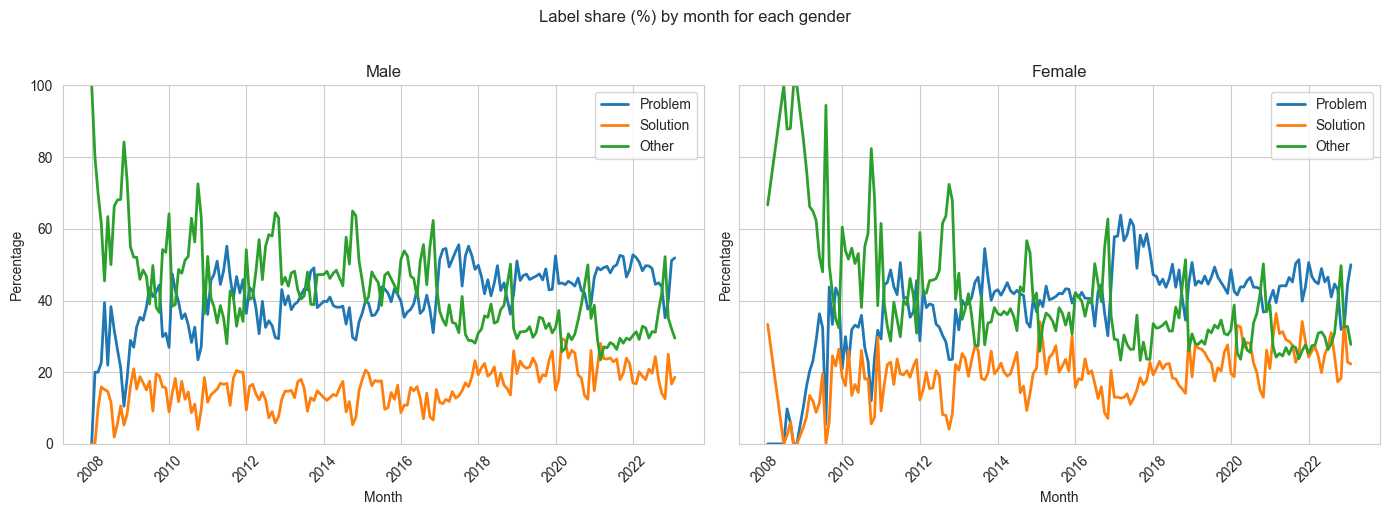

In [23]:
# 7. Label share (%) by month - Male vs Female (2 subplots)
gender_label_month = df.groupby(['month', 'gender', 'label']).size().unstack(fill_value=0)
gender_label_month = gender_label_month.div(gender_label_month.sum(axis=1), axis=0) * 100
gender_label_month = gender_label_month.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for i, gender in enumerate(['Male', 'Female']):
    ax = axes[i]
    subset = gender_label_month[gender_label_month['gender'] == gender]
    subset = subset.set_index('month')
    subset.index = subset.index.to_timestamp()
    for label in ['Problem', 'Solution', 'Other']:
        if label in subset.columns:
            ax.plot(subset.index, subset[label], label=label, linewidth=2)
    ax.set_xlabel('Month')
    ax.set_ylabel('Percentage')
    ax.set_title(f'{gender}')
    ax.legend()
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Label share (%) by month for each gender', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

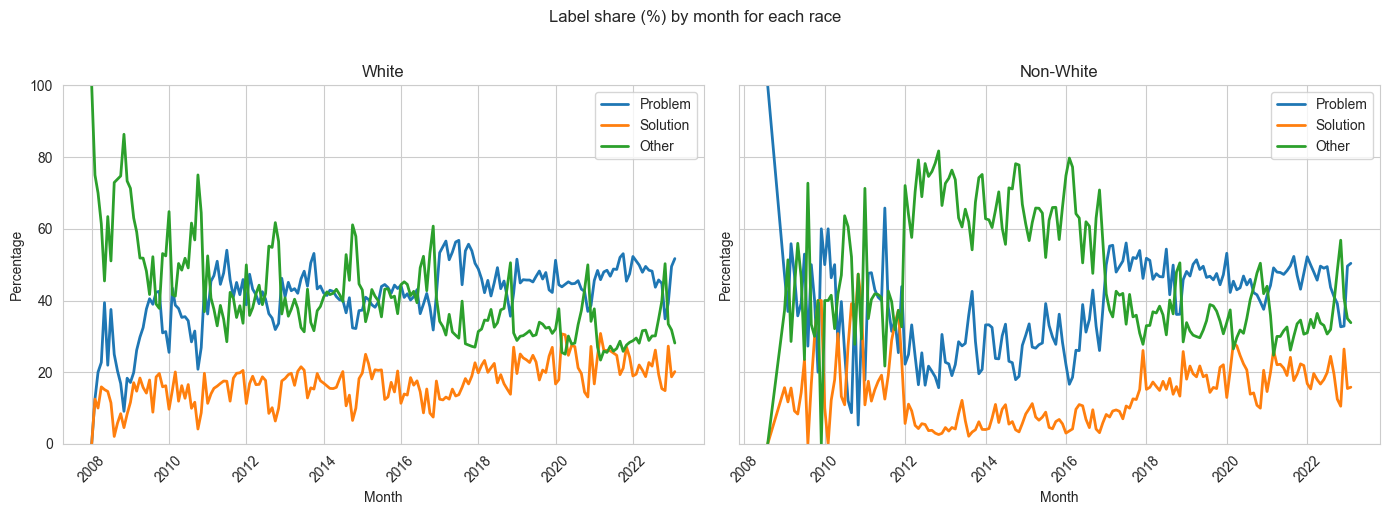

In [24]:
# 8. Label share (%) by month - White vs Non-White (2 subplots)
race_label_month = df.groupby(['month', 'race', 'label']).size().unstack(fill_value=0)
race_label_month = race_label_month.div(race_label_month.sum(axis=1), axis=0) * 100
race_label_month = race_label_month.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for i, race in enumerate(['White', 'Non-White']):
    ax = axes[i]
    subset = race_label_month[race_label_month['race'] == race]
    subset = subset.set_index('month')
    subset.index = subset.index.to_timestamp()
    for label in ['Problem', 'Solution', 'Other']:
        if label in subset.columns:
            ax.plot(subset.index, subset[label], label=label, linewidth=2)
    ax.set_xlabel('Month')
    ax.set_ylabel('Percentage')
    ax.set_title(f'{race}')
    ax.legend()
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Label share (%) by month for each race', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

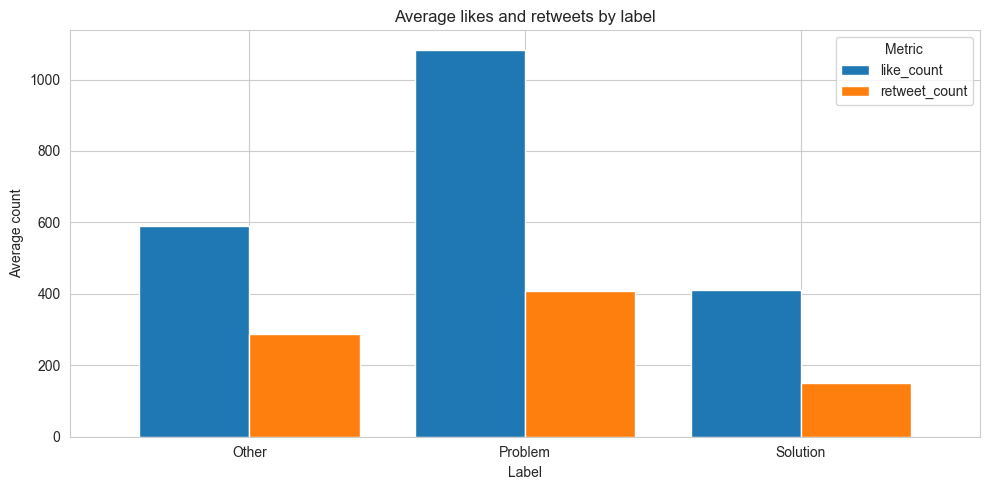

In [25]:
# 9. Engagement: average likes and retweets by label
engagement = df.groupby('label')[['like_count', 'retweet_count']].mean()
engagement.plot(kind='bar', figsize=(10, 5), width=0.8)
plt.xlabel('Label')
plt.ylabel('Average count')
plt.title('Average likes and retweets by label')
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [28]:
print(df.columns)

Index(['Unnamed: 0', 'tweet_id', 'text', 'confidence_Problem',
       'confidence_Solution', 'confidence_Other', 'label', 'max_confidence',
       'party', 'gender', 'race', 'state', 'user_handle', 'tw_date',
       'retweet_count', 'like_count', 'sen_id', 'month'],
      dtype='object')
